In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 에러 해결을 위한 임포트 추가
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from xgboost import XGBClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor

## step1. 최적의 K 찾기

In [2]:
# 데이터 로드
df = pd.read_csv('05_merged_dataset.csv')

# 결측치 제거 및 클러스터링 대상 피처(premium_ratio) 추출
df_clean = df.dropna(subset=['premium_ratio']).copy()
X_cluster = df_clean[['premium_ratio']]

# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [3]:
# 평가할 K의 범위 : k의 범위를 2에서 6까지 한정
k_range = range(2, 7)
inertias = []
silhouette_scores = []

for k in k_range:
    # K-Means 모델 학습
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # 관성 계산: Elbow Method용
    inertias.append(kmeans.inertia_)
    
    # 실루엣 점수 계산
    score = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    silhouette_scores.append(score)
    
    print(f"   ▶ [K={k}] 일때 실루엣 점수: {score:.4f}")

   ▶ [K=2] 일때 실루엣 점수: 0.9034
   ▶ [K=3] 일때 실루엣 점수: 0.7129
   ▶ [K=4] 일때 실루엣 점수: 0.6176
   ▶ [K=5] 일때 실루엣 점수: 0.5947
   ▶ [K=6] 일때 실루엣 점수: 0.5788


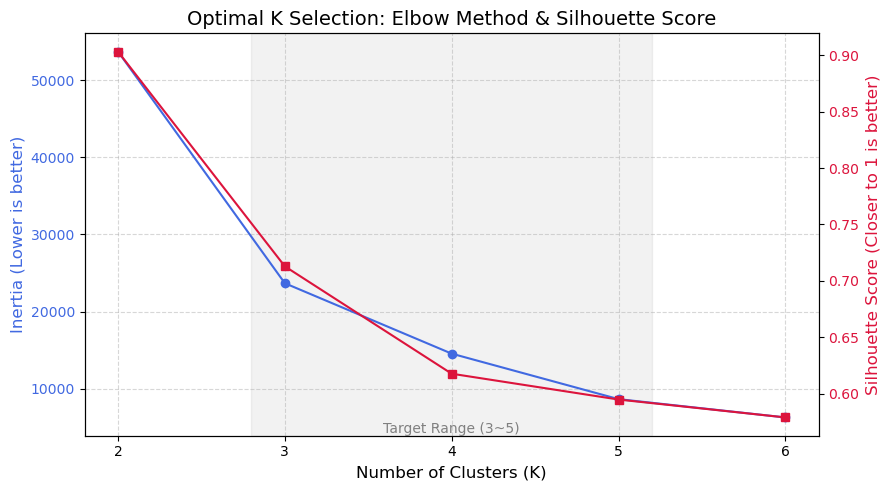

In [4]:
# 결과 시각화 
fig, ax1 = plt.subplots(figsize=(9, 5))

# 관성(Inertia) 그래프 (파란색)
ax1.plot(k_range, inertias, marker='o', color='royalblue', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Lower is better)', color='royalblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--', alpha=0.5)

# 실루엣 점수 그래프 (빨간색)
ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, marker='s', color='crimson', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score (Closer to 1 is better)', color='crimson', fontsize=12)
ax2.tick_params(axis='y', labelcolor='crimson')

# 목표 범위(3~5) 시각적 강조
ax1.axvspan(2.8, 5.2, color='gray', alpha=0.1)
plt.text(4, ax2.get_ylim()[0], 'Target Range (3~5)', ha='center', va='bottom', color='gray', fontsize=10)

plt.title('Optimal K Selection: Elbow Method & Silhouette Score', fontsize=14)
fig.tight_layout()
plt.show()

# Step2.모델 학습 및 test-set 적용

In [5]:
df = pd.read_csv('05_merged_dataset.csv')
df_clean = df.dropna(subset=['premium_ratio']).copy()

# 라벨링용 로그 스케일링 및 K-Means
df_clean['log_premium_ratio'] = np.log1p(df_clean['premium_ratio'])
scaler = StandardScaler()
premium_scaled = scaler.fit_transform(df_clean[['log_premium_ratio']])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clean['premium_lable'] = kmeans.fit_predict(premium_scaled)

# 라벨 정렬 (0: 하락 ~ 4: 폭등)
order = df_clean.groupby('premium_lable')['premium_ratio'].mean().sort_values().index
mapping = {old: new for new, old in enumerate(order)}
df_clean['premium_lable'] = df_clean['premium_lable'].map(mapping)

In [6]:
# 피처엔지니어링 진행 
def calculate_balanced_weight(row):
    base = (row['google_trend_release'] * row['google_trend_n_day']) / \
           (row['google_trend_release'] + row['google_trend_n_day'] + 1)
    p_ratio = row['premium_ratio']
    weight = 1 + np.log1p(max(0, p_ratio)) * 3 
    return base * weight

df_clean['adjusted_google_trend'] = df_clean.apply(calculate_balanced_weight, axis=1)
df_clean['wish_per_day'] = (df_clean['wish_count'] * (1 + np.sqrt(abs(df_clean['premium_ratio'])))) / (df_clean['days_since_first_trade'] + 1)
df_clean['trend_retention'] = df_clean['google_trend_n_day'] / (df_clean['google_trend_release'] + 1)
df_clean['wish_efficiency'] = (df_clean['cum_trade_count_product'] * (1 + np.sqrt(abs(df_clean['premium_ratio'])))) / (df_clean['wish_count'] + 1)
df_clean['log_release_price'] = np.log1p(df_clean['release_price'])
df_clean['adjusted_wish'] = df_clean['wish_per_day']

# 학습 데이터 준비
drop_cols = ['product_id', 'first_trade_date', 'trade_date', 'release_date', 
             'current_price', 'premium_ratio', 'premium_lable', 'log_premium_ratio']
X = df_clean.drop(columns=drop_cols)
y = df_clean['premium_lable']
groups = df_clean['product_id']

In [7]:
#클래스 분포 확인
print("\n 클래스 분포 확인 :")
print(y.value_counts(normalize=True).sort_index())

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 불균형 해소를 위한 샘플 가중치
class_weights = {0: 1.0, 1: 1.0, 2: 2.5, 3: 1.2, 4: 1.2}
sample_weights = np.array([class_weights[label] for label in y_train])


 클래스 분포 확인 :
premium_lable
0    0.219385
1    0.351207
2    0.289956
3    0.115594
4    0.023859
Name: proportion, dtype: float64



 1차 모델 학습
              precision    recall  f1-score   support

           0       0.66      0.31      0.42      8735
           1       0.69      0.90      0.78     15310
           2       0.98      0.97      0.98     10385
           3       1.00      0.92      0.96      4544
           4       0.80      1.00      0.89       958

    accuracy                           0.80     39932
   macro avg       0.83      0.82      0.81     39932
weighted avg       0.80      0.80      0.78     39932



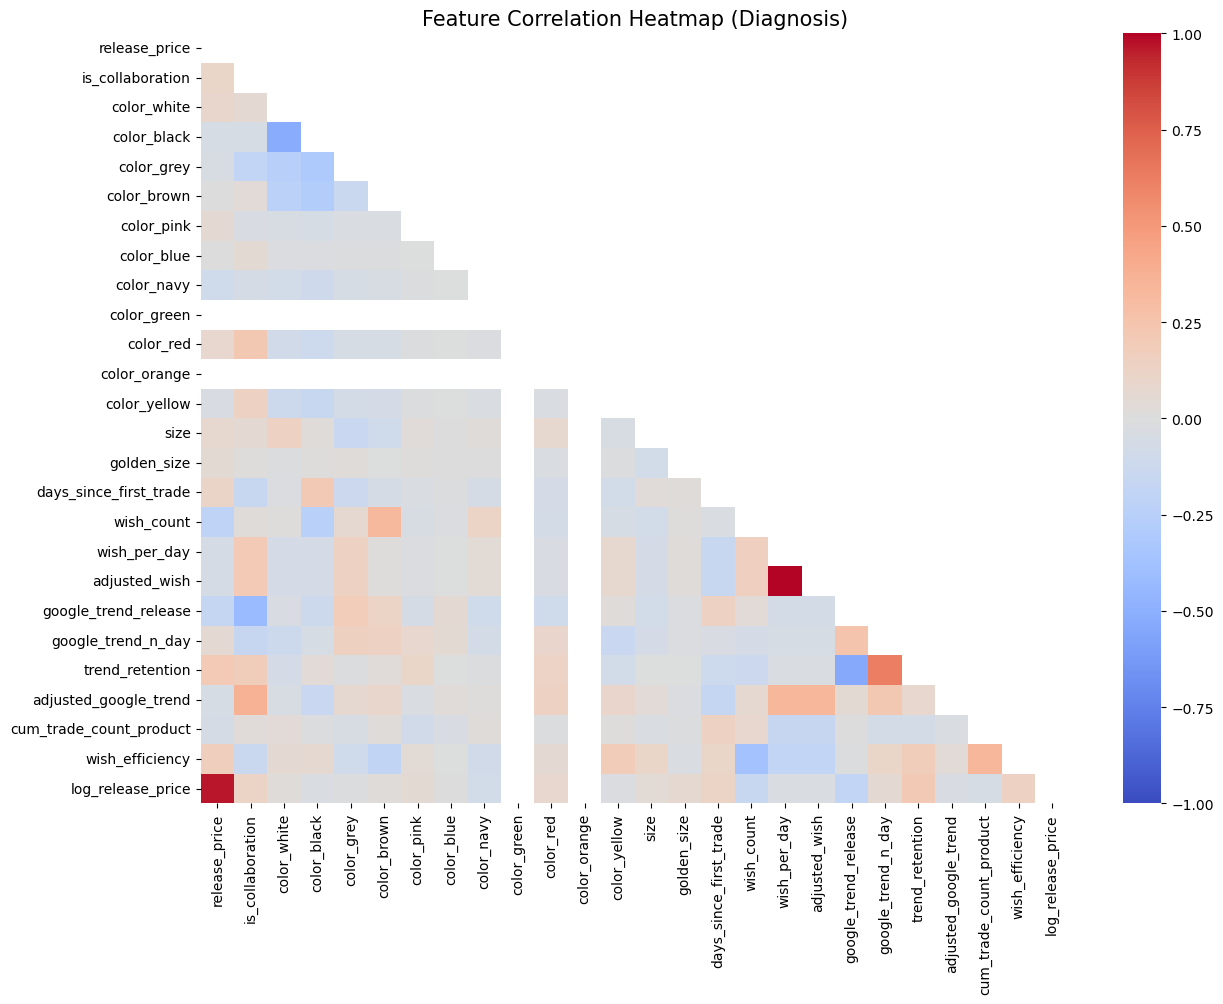

In [8]:
# 1차 학습 진행
print("\n 1차 모델 학습")
xgb_base = XGBClassifier(n_estimators=1000, learning_rate=0.03, max_depth=10, random_state=42, tree_method='hist')
xgb_base.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_base = xgb_base.predict(X_test)

# 지표 계산
base_acc = accuracy_score(y_test, y_pred_base)
base_f1_w = f1_score(y_test, y_pred_base, average='weighted')
base_f1_m = f1_score(y_test, y_pred_base, average='macro')

print(classification_report(y_test, y_pred_base))

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 학습데이터로 상관관계 계산.
corr = X_train.corr()

# 2. 히트맵 시각화
plt.figure(figsize=(14, 10))


mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, 
            mask=mask, 
            annot=False,        
            cmap='coolwarm',    # 빨간색일수록 양의 상관관계, 파란색일수록 음의 상관관계
            center=0, 
            vmin=-1, vmax=1)

plt.title('Feature Correlation Heatmap (Diagnosis)', fontsize=15)
plt.show()

In [9]:
importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': xgb_base.feature_importances_}).sort_values(by='importance', ascending=False)
candidate_features = importance_df['feature'].tolist()
selected_features = []

for f in candidate_features:
    temp_list = selected_features + [f]
    if len(temp_list) > 1:
        # VIF 계산 : 현재 후보 피처가 추가되었을 때의 다중공선성 확인
        vif = variance_inflation_factor(X_train[temp_list].values, len(temp_list) - 1)
        if vif < 10: 
            selected_features.append(f)
    else: 
        selected_features.append(f)
    
    # 상위 10개만 수집
    if len(selected_features) >= 10: 
        break

print(f"최종 선정된 feature (10개):")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")


최종 선정된 feature (10개):
1. is_collaboration
2. adjusted_google_trend
3. release_price
4. google_trend_release
5. wish_count
6. color_brown
7. color_yellow
8. color_black
9. wish_per_day
10. days_since_first_trade


              precision    recall  f1-score   support

           0       0.81      0.22      0.35      8735
           1       0.66      0.94      0.77     15310
           2       0.93      0.89      0.91     10385
           3       0.89      0.99      0.94      4544
           4       0.97      0.77      0.86       958

    accuracy                           0.77     39932
   macro avg       0.85      0.76      0.77     39932
weighted avg       0.80      0.77      0.74     39932

      Metric (평가지표) Baseline 모델 2차 정제 모델     변화량
           Accuracy      0.7962   0.7701 -0.0261
F1-Score (Weighted)      0.7765   0.7361 -0.0404
   F1-Score (Macro)      0.8057   0.7653 -0.0404
           사용한 피처 수          26       10     -16


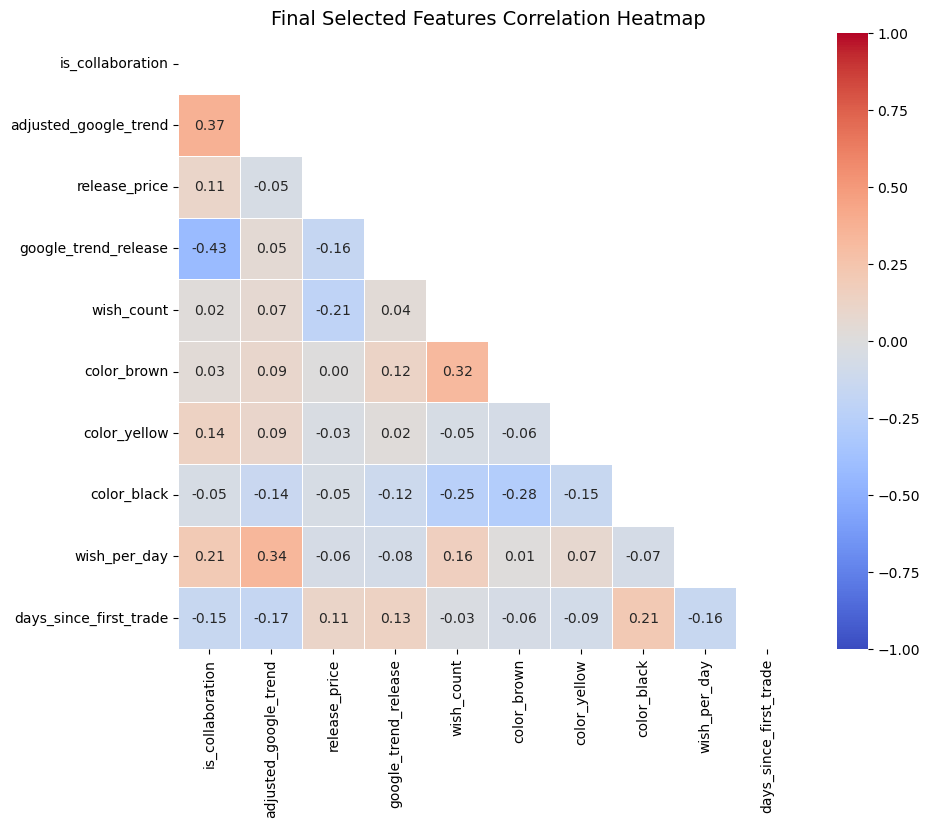

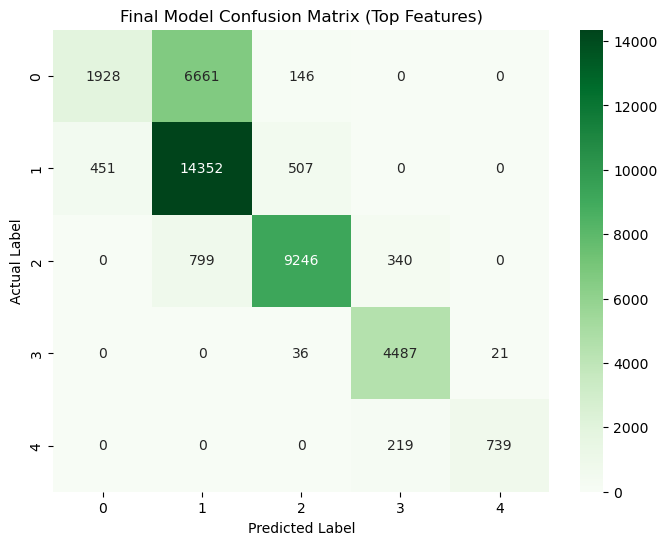

In [10]:
# 2차 학습 진행
X_train_final = X_train[selected_features]
X_test_final = X_test[selected_features]

xgb_final = XGBClassifier(n_estimators=1000, learning_rate=0.03, max_depth=10, random_state=42, tree_method='hist')
xgb_final.fit(X_train_final, y_train, sample_weight=sample_weights)

y_pred_final = xgb_final.predict(X_test_final)

# 지표 계산
final_acc = accuracy_score(y_test, y_pred_final)
final_f1_w = f1_score(y_test, y_pred_final, average='weighted')
final_f1_m = f1_score(y_test, y_pred_final, average='macro')



print(classification_report(y_test, y_pred_final))

# 2. 모델 성능 비교 요약표 (Accuracy, F1-Score 포함)
performance_compare = pd.DataFrame({
    'Metric (평가지표)': ['Accuracy', 'F1-Score (Weighted)', 'F1-Score (Macro)', '사용한 피처 수'],
    'Baseline 모델': [
        f"{base_acc:.4f}", 
        f"{f1_score(y_test, y_pred_base, average='weighted'):.4f}",
        f"{f1_score(y_test, y_pred_base, average='macro'):.4f}",
        len(X_train.columns)
    ],
    '2차 정제 모델': [
        f"{final_acc:.4f}", 
        f"{final_f1_w:.4f}",
        f"{final_f1_m:.4f}",
        len(selected_features)
    ],
    '변화량': [
        f"{final_acc - base_acc:+.4f}", 
        f"{final_f1_w - f1_score(y_test, y_pred_base, average='weighted'):+.4f}",
        f"{final_f1_m - f1_score(y_test, y_pred_base, average='macro'):+.4f}",
        f"{len(selected_features) - len(X_train.columns)}"
    ]
})


print(performance_compare.to_string(index=False))



# 상관계수 계산 및 히트맵
corr_final = X_train_final.corr()

plt.figure(figsize=(10, 8))

# 상단 삼각형 마스킹 처리 (1차와 동일한 로직)
mask_final = np.triu(np.ones_like(corr_final, dtype=bool))

sns.heatmap(corr_final, 
            mask=mask_final, 
            annot=True,          
            cmap='coolwarm', 
            center=0, 
            vmin=-1, vmax=1,
            fmt=".2f",
            linewidths=.5)       

plt.title("Final Selected Features Correlation Heatmap", fontsize=14)
plt.show()

# 4. 최종 Confusion Matrix 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Greens')
plt.title('Final Model Confusion Matrix (Top Features)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

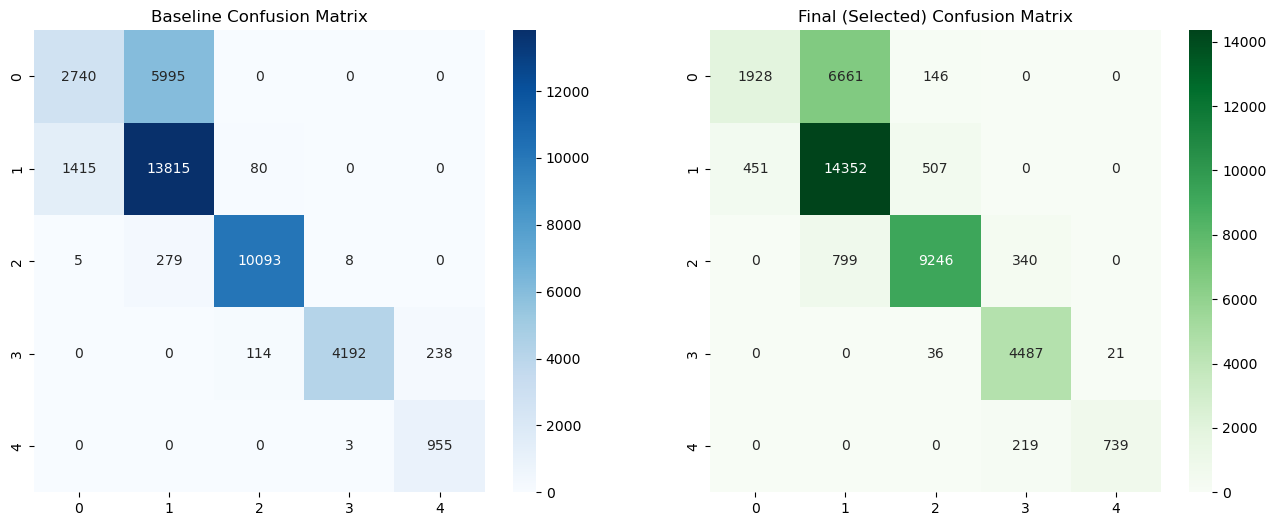

In [11]:
performance_df = pd.DataFrame({
    'Metric (평가지표)': ['Accuracy', 'F1-Score (Weighted)', 'F1-Score (Macro)', '사용한 피처 수'],
    'Baseline 모델': [f"{base_acc:.4f}", f"{base_f1_w:.4f}", f"{base_f1_m:.4f}", len(X_train.columns)],
    '2차 정제 모델': [f"{final_acc:.4f}", f"{final_f1_w:.4f}", f"{final_f1_m:.4f}", len(selected_features)],
    '변화량': [f"{final_acc - base_acc:+.4f}", f"{final_f1_w - base_f1_w:+.4f}", f"{final_f1_m - base_f1_m:+.4f}", f"{len(selected_features) - len(X_train.columns)}"]
})

# Confusion Matrix 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_base), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Baseline Confusion Matrix')
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Final (Selected) Confusion Matrix')
plt.show()

## Step3.실제 제품으로 테스트

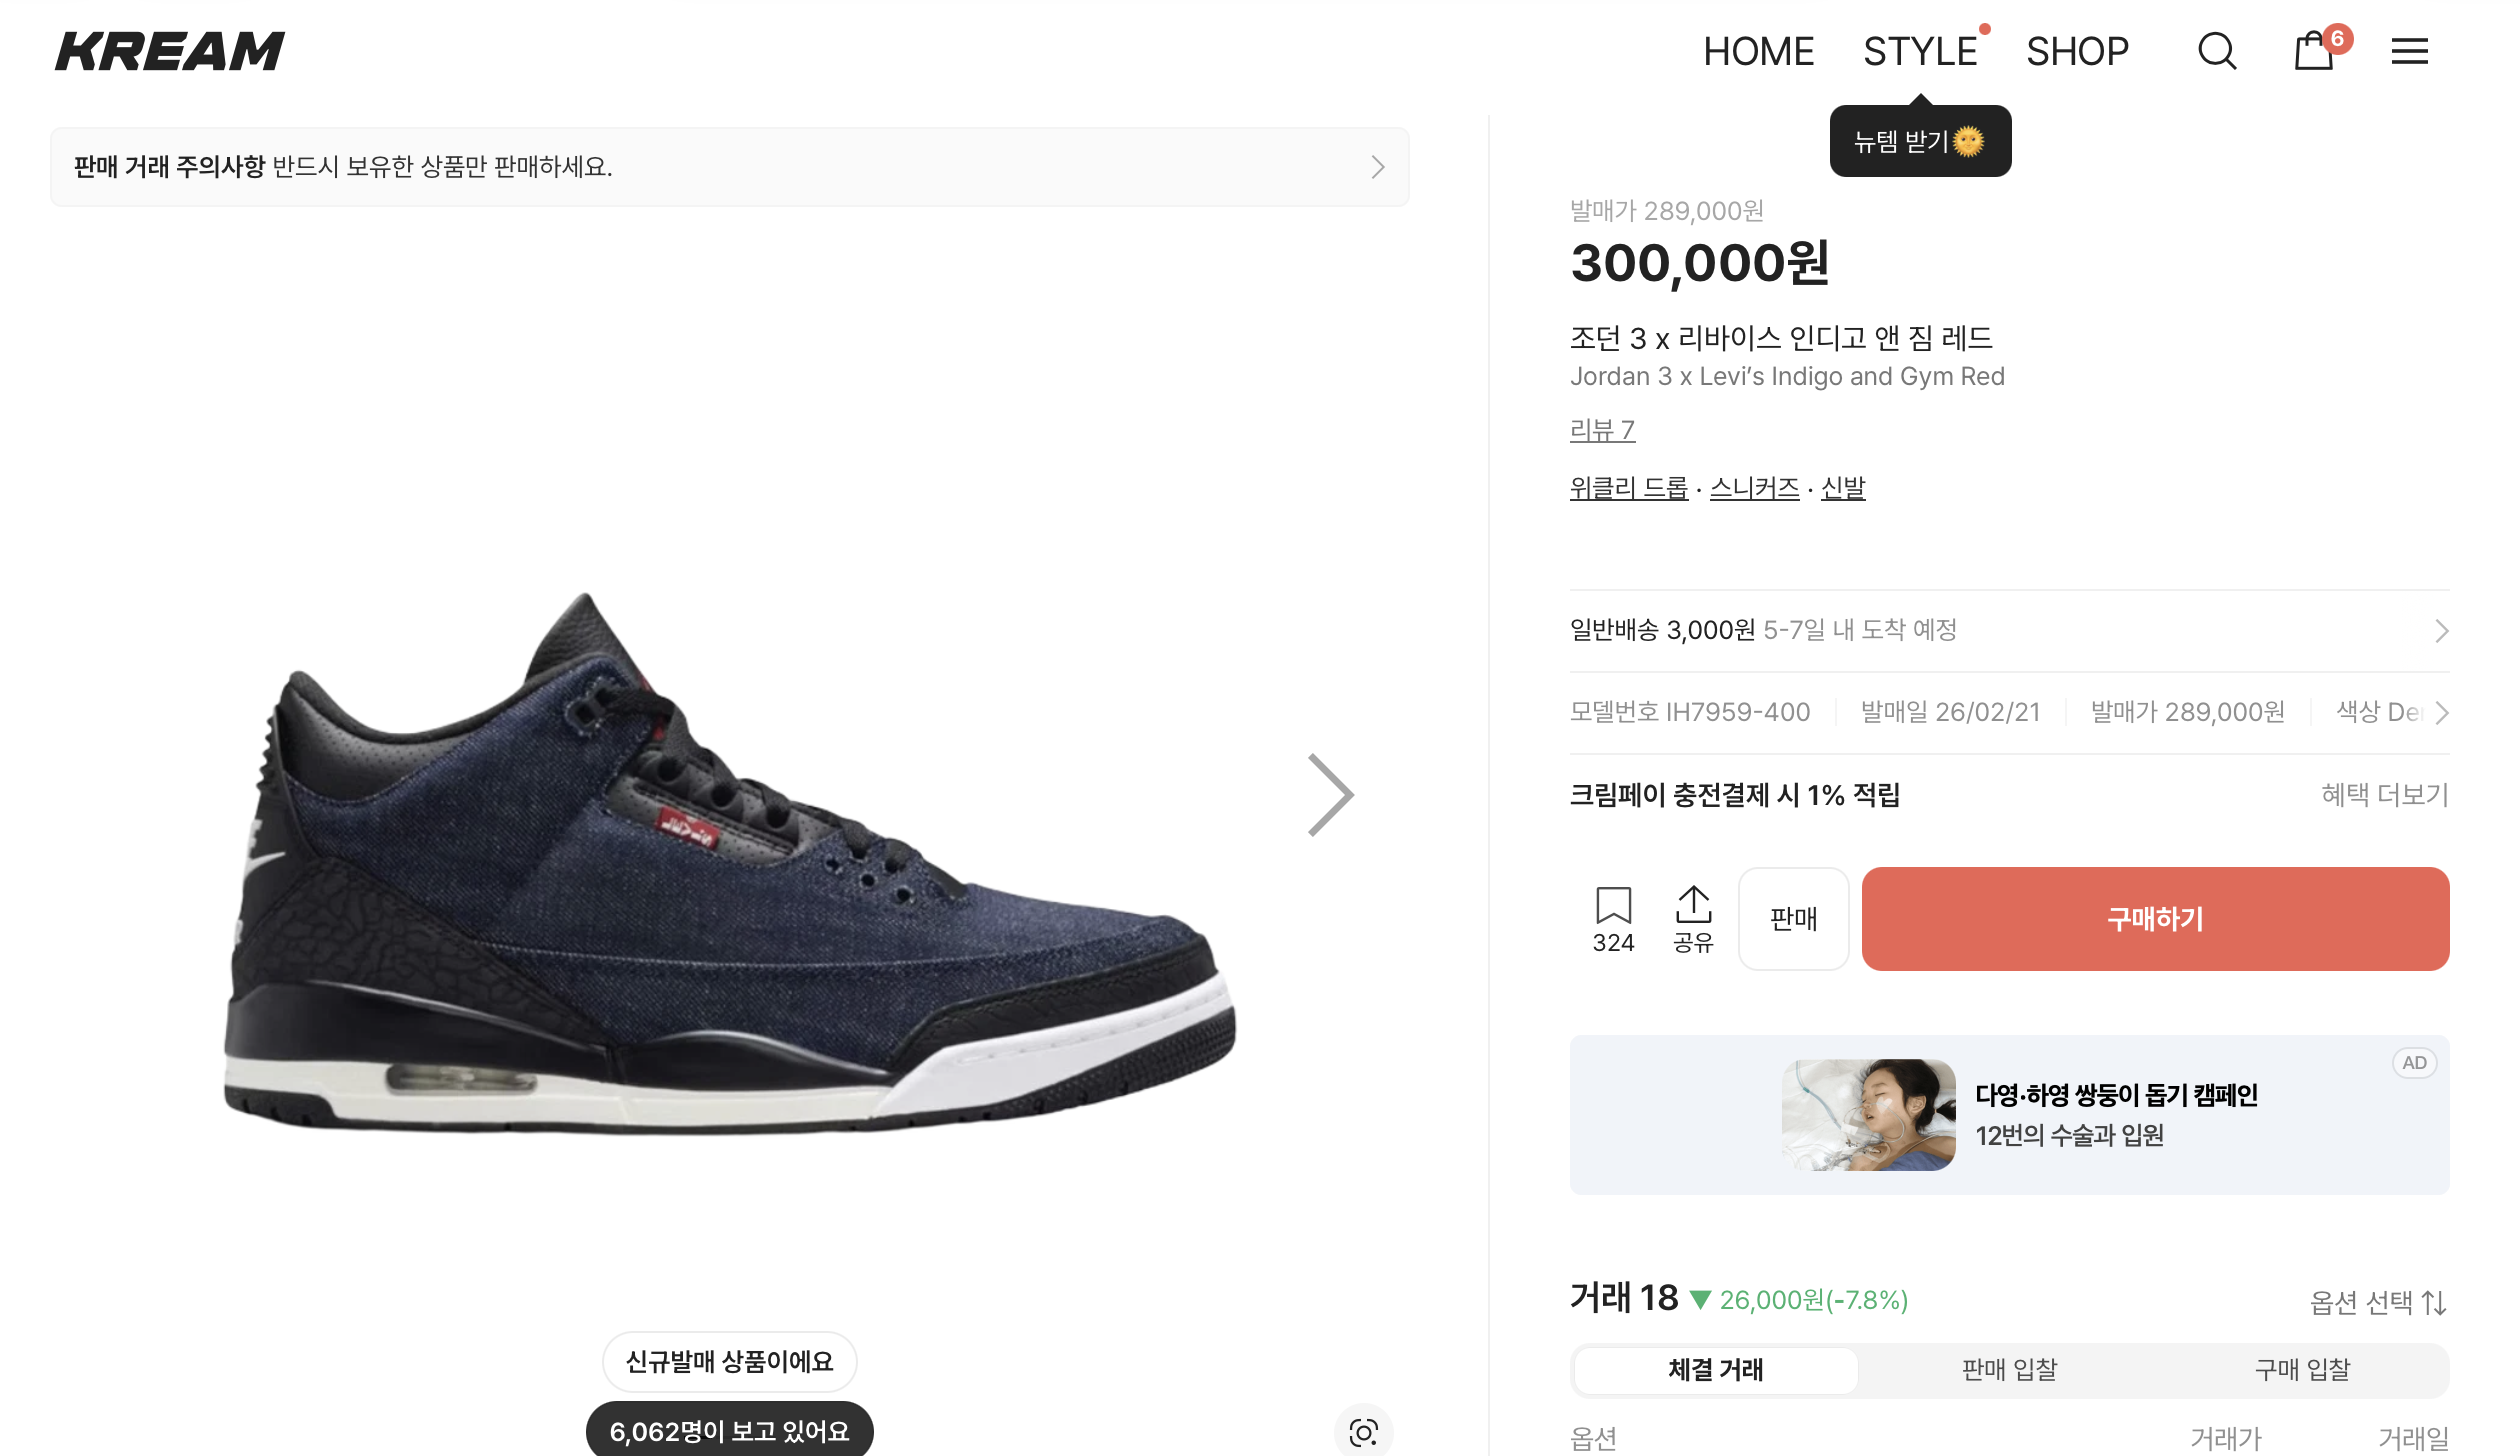

In [14]:

new_shoes_data = {
    'product_id': [791202],
    'release_price': [289000],
    'is_collaboration': [0],
    'color_white': [0], 'color_black': [1], 'color_grey': [0], 
    'color_brown': [0], 'color_pink': [0], 'color_blue': [0], 
    'color_navy': [0], 'color_green': [0], 'color_red': [0], 
    'color_orange': [0], 'color_yellow': [0],
    'size': [275],
    'golden_size': [1],
    'days_since_first_trade': [2],
    'current_price': [300000],
    'cum_trade_count_product': [18],
    'wish_count': [324],
    'google_trend_release': [71],
    'google_trend_n_day': [69]
}

final_df = pd.DataFrame(new_shoes_data)

# 2. 파생 변수 로직 적용
# 프리미엄 비율 계산
final_df['premium_ratio'] = (final_df['current_price'] - final_df['release_price']) / final_df['release_price']

# 구글 트렌드 가중치 계산 (calculate_balanced_weight 함수 사용)
final_df['adjusted_google_trend'] = final_df.apply(calculate_balanced_weight, axis=1)

# 일일 위시/트렌드 유지력 등 계산
final_df['wish_per_day'] = (final_df['wish_count'] * (1 + np.sqrt(abs(final_df['premium_ratio'])))) / (final_df['days_since_first_trade'] + 1)
final_df['trend_retention'] = final_df['google_trend_n_day'] / (final_df['google_trend_release'] + 1)
final_df['wish_efficiency'] = (final_df['cum_trade_count_product'] * (1 + np.sqrt(abs(final_df['premium_ratio'])))) / (final_df['wish_count'] + 1)
final_df['log_release_price'] = np.log1p(final_df['release_price'])

final_df['adjusted_wish'] = final_df['wish_per_day']

# 3. 핵심 피처(selected_features)만 추출
final_input = final_df[selected_features]

# 4. 최종 모델로 라벨 예측
predicted_label = xgb_final.predict(final_input)[0]
predicted_proba = xgb_final.predict_proba(final_input)[0]

# 5. 결과 출력
print(f" 예측 결과: [라벨 {predicted_label}]")
print(f" 모델 확신도: {np.max(predicted_proba)*100:.2f}%\n")

# 라벨 해석 로직
if predicted_label == 0:
    print("[결과: 하락 추정] 이후 가격이 하락할 것으로 예측됩니다.")
elif predicted_label == 1:
    print("[결과: 안정] 이후 가격 변동폭이 적을 것으로 예측됩니다.")
elif predicted_label == 2:
    print("[결과: 상승] 이후 가격이 완만하게 상승할 것으로 예측됩니다.")
elif predicted_label == 3:
    print("[결과: 급상승] 인기 급증으로, 이후 가격이 급격하게 상승할 것으로 보입니다.")
else:
    print("[결과: 폭등] 매우 높은 프리미엄 유지가 예상됩니다.")

 예측 결과: [라벨 1]
 모델 확신도: 96.08%

[결과: 안정] 이후 가격 변동폭이 적을 것으로 예측됩니다.


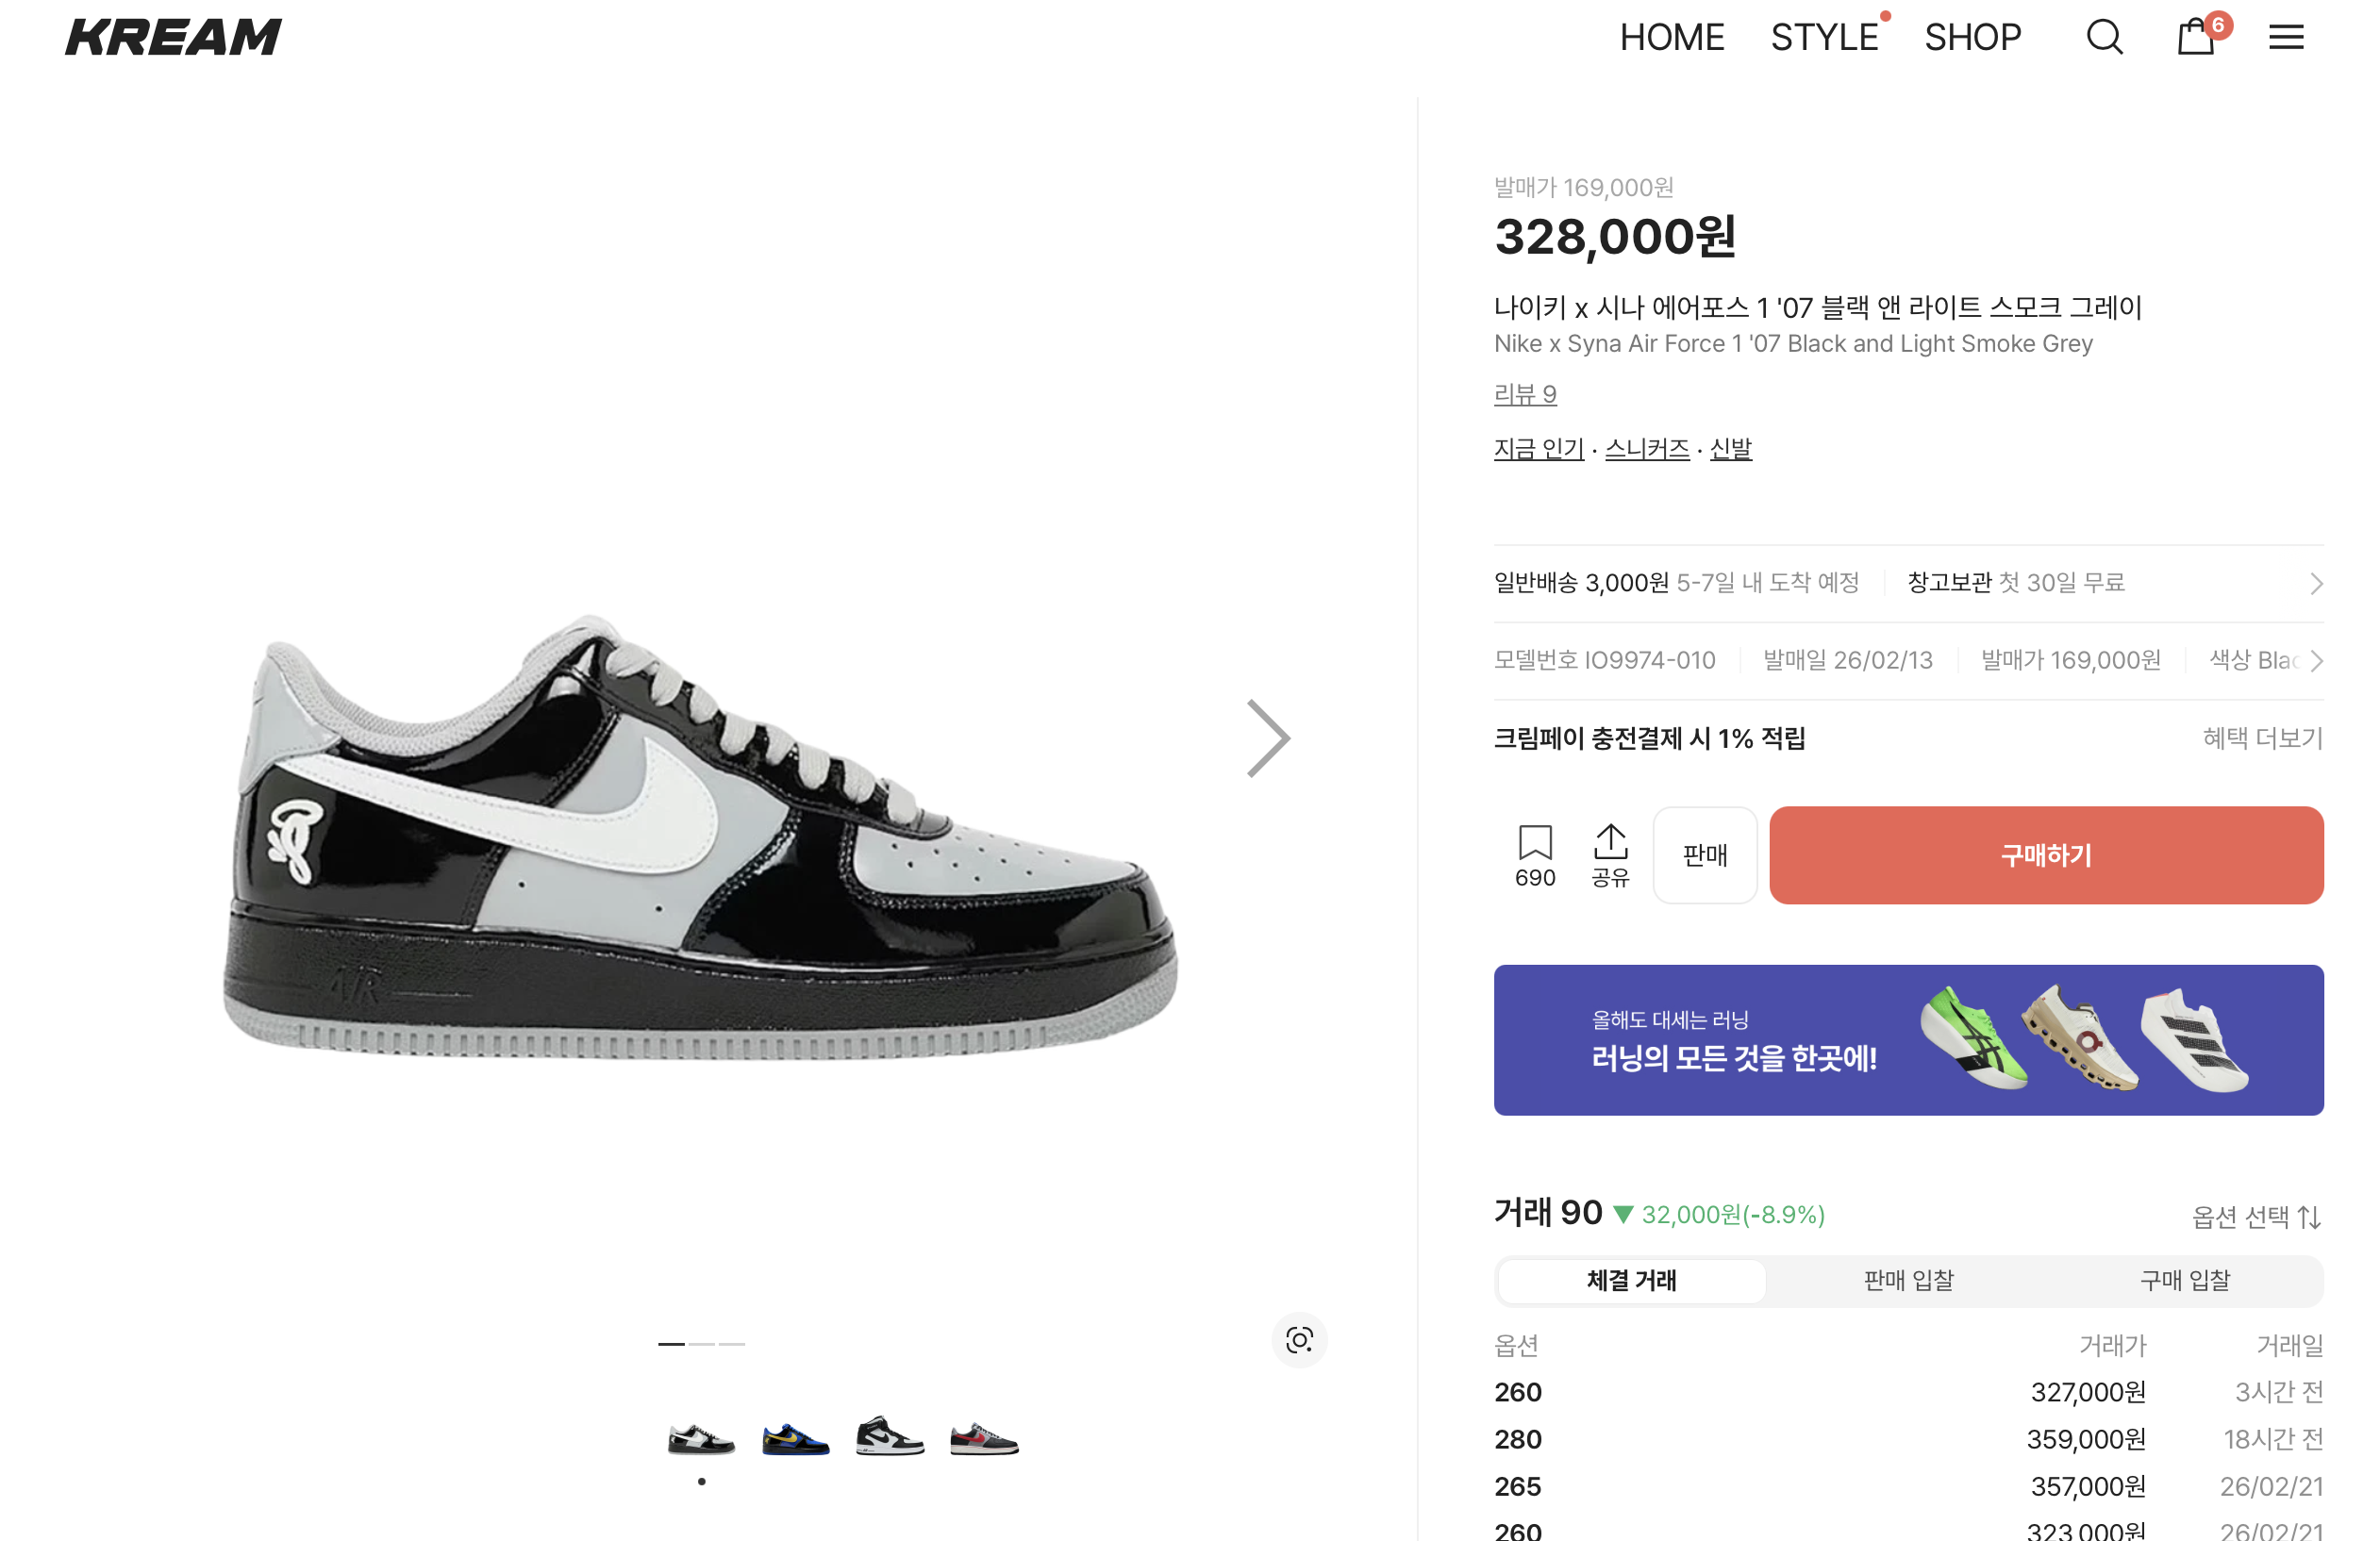

In [15]:


# 1. 두 번째 상품 데이터 정의
new_shoes_data_2 = {
    'product_id': [783522],
    'release_price': [169000],
    'is_collaboration': [0],
    'color_white': [0], 'color_black': [1], 'color_grey': [0], 
    'color_brown': [0], 'color_pink': [0], 'color_blue': [0], 
    'color_navy': [0], 'color_green': [0], 'color_red': [0], 
    'color_orange': [0], 'color_yellow': [0],
    'size': [270],
    'golden_size': [1],
    'days_since_first_trade': [66],
    'current_price': [384000],
    'cum_trade_count_product': [90],
    'wish_count': [690],
    'google_trend_release': [75],
    'google_trend_n_day': [69]
}

final_df = pd.DataFrame(new_shoes_data_2)

# 2. 파생 변수 로직 적용
# 프리미엄 비율 계산
final_df['premium_ratio'] = (final_df['current_price'] - final_df['release_price']) / final_df['release_price']

# 구글 트렌드 가중치 계산 (calculate_balanced_weight 함수 사용)
final_df['adjusted_google_trend'] = final_df.apply(calculate_balanced_weight, axis=1)

# 일일 위시/트렌드 유지력 등 계산
final_df['wish_per_day'] = (final_df['wish_count'] * (1 + np.sqrt(abs(final_df['premium_ratio'])))) / (final_df['days_since_first_trade'] + 1)
final_df['trend_retention'] = final_df['google_trend_n_day'] / (final_df['google_trend_release'] + 1)
final_df['wish_efficiency'] = (final_df['cum_trade_count_product'] * (1 + np.sqrt(abs(final_df['premium_ratio'])))) / (final_df['wish_count'] + 1)
final_df['log_release_price'] = np.log1p(final_df['release_price'])


final_df['adjusted_wish'] = final_df['wish_per_day']

# 3. 핵심 피처(selected_features)만 추출
final_input = final_df[selected_features]

# 4. 최종 모델로 라벨 예측
predicted_label = xgb_final.predict(final_input)[0]
predicted_proba = xgb_final.predict_proba(final_input)[0]

# 5. 결과 출력
print(f" 예측 결과: [라벨 {predicted_label}]")
print(f" 모델 확신도: {np.max(predicted_proba)*100:.2f}%")


# 라벨 해석 로직
if predicted_label == 0:
    print("[결과: 하락 추정] 이후 가격이 하락할 것으로 예측됩니다.")
elif predicted_label == 1:
    print("[결과: 안정] 이후 가격 변동폭이 적을 것으로 예측됩니다. ")
elif predicted_label == 2:
    print("[결과: 상승] 이후 가격이 완만하게 상승할 것으로 예측됩니다.")
elif predicted_label == 3:
    print("[결과: 급상승] 인기 급증으로, 이후 가격이 급격하게 상승할 것으로 보입니다. ")
else:
    print("[결과: 폭등] 매우 높은 프리미엄 유지가 예상됩니다.")


 예측 결과: [라벨 3]
 모델 확신도: 99.99%
[결과: 급상승] 인기 급증으로, 이후 가격이 급격하게 상승할 것으로 보입니다. 
